# **1. Data Understanding**

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
data = pd.read_csv("/content/sentiment_data.csv")
data.columns = data.columns.str.lower() # Convert column names to lowercase

In [77]:
data.head()

,unnamed: 0,comment,sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2


(241145, 3)
sentiment
2    103059
1     82972
0     55114
Name: count, dtype: int64


<Axes: xlabel='sentiment', ylabel='count'>

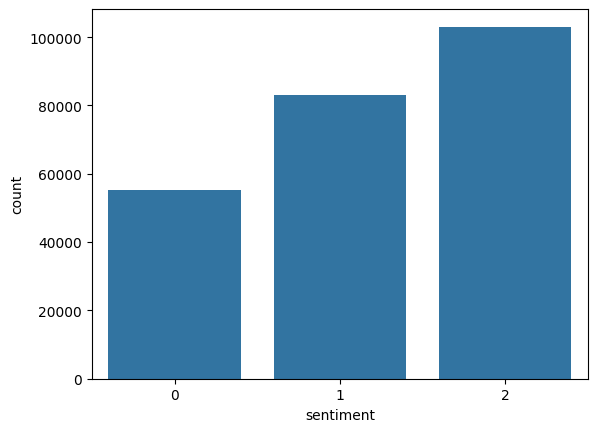

In [78]:
print(data.shape)
print(data['sentiment'].value_counts())

import seaborn as sns
sns.countplot(x='sentiment', data=data)


In [79]:
data.columns

Index(['unnamed: 0', 'comment', 'sentiment'], dtype='object')

In [80]:
data = data.drop(["unnamed: 0"], axis = 1)

In [81]:
data.head()

,comment,sentiment
0,lets forget apple pay required brand new iphon...,1
1,nz retailers don’t even contactless credit car...,0
2,forever acknowledge channel help lessons ideas...,2
3,whenever go place doesn’t take apple pay doesn...,0
4,apple pay convenient secure easy use used kore...,2


# **2. NLP Preprocessing**

In [57]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    # 1. Lowercasing
    text = text.lower()

    # 2. Removing URLs, special characters and punctuation (regex handles punctuation too)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'[^a-z0-9\s]', '', text) # Keep only alphanumeric and spaces (removes punctuation)

    # 3. Tokenization
    tokens = word_tokenize(text)

    # 4. Removing stopwords and Lemmatization
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return " ".join(lemmatized_tokens)

# Apply the preprocessing function to the 'Comment' column
data['processed_comment'] = data['comment'].apply(preprocess_text)

# Display the first few rows with the new processed column
print(data[['comment', 'processed_comment']].head())

                                             comment  \
0  lets forget apple pay required brand new iphon...   
1  nz retailers don’t even contactless credit car...   
2  forever acknowledge channel help lessons ideas...   
3  whenever go place doesn’t take apple pay doesn...   
4  apple pay convenient secure easy use used kore...   

                                   processed_comment  
0  let forget apple pay required brand new iphone...  
1  nz retailer dont even contactless credit card ...  
2  forever acknowledge channel help lesson idea e...  
3  whenever go place doesnt take apple pay doesnt...  
4  apple pay convenient secure easy use used kore...  


# **3. Feature Engineering**

In [58]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Bag of Words (BoW)
print("Applying Bag of Words (BoW)...")
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(data['processed_comment'])
print(f"Shape of BoW matrix: {bow_matrix.shape}")

# TF-IDF
print("\nApplying TF-IDF...")
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(data['processed_comment'])
print(f"Shape of TF-IDF matrix: {tfidf_matrix.shape}")

Applying Bag of Words (BoW)...
Shape of BoW matrix: (241145, 140143)

Applying TF-IDF...
Shape of TF-IDF matrix: (241145, 140143)


# **4. Model Building**

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report


x = tfidf_matrix
y = data['sentiment'] # Changed 'Sentiment' to 'sentiment' for consistency

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [61]:
logistic_regression_model = LogisticRegression()
logistic_regression_model.fit(x_train, y_train)
logistic_regression_predictions = logistic_regression_model.predict(x_test)
logistic_regression_accuracy = accuracy_score(y_test, logistic_regression_predictions)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [62]:
naive_bayes_model = MultinomialNB()
naive_bayes_model.fit(x_train, y_train)
naive_bayes_predictions = naive_bayes_model.predict(x_test)
naive_bayes_accuracy = accuracy_score(y_test, naive_bayes_predictions)

In [63]:
decision_tree_model = DecisionTreeClassifier()
decision_tree_model.fit(x_train, y_train)
decision_tree_predictions = decision_tree_model.predict(x_test)

# **5. Model Evaluation**

In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Initialize a dictionary to store results
results = {}

# --- Logistic Regression ---
results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, logistic_regression_predictions),
    'Precision': precision_score(y_test, logistic_regression_predictions, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, logistic_regression_predictions, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, logistic_regression_predictions, average='weighted', zero_division=0)
}

# --- Naive Bayes ---
results['Naive Bayes'] = {
    'Accuracy': accuracy_score(y_test, naive_bayes_predictions),
    'Precision': precision_score(y_test, naive_bayes_predictions, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, naive_bayes_predictions, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, naive_bayes_predictions, average='weighted', zero_division=0)
}

# --- Decision Tree ---
results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, decision_tree_predictions),
    'Precision': precision_score(y_test, decision_tree_predictions, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, decision_tree_predictions, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, decision_tree_predictions, average='weighted', zero_division=0)
}

# Convert results to DataFrame for neat display
results_df = pd.DataFrame(results).T

# Print the comparison table
print("\n--- Model Performance Comparison ---")
print(results_df.round(4))

# Optionally, highlight the best performing model based on F1-Score
best_model = results_df['F1-Score'].idxmax()
print(f"\nBest performing model (based on F1-Score): {best_model}")


--- Model Performance Comparison ---
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.7833     0.7853  0.7833    0.7820
Naive Bayes            0.5833     0.6737  0.5833    0.5392
Decision Tree          0.7844     0.7835  0.7844    0.7836

Best performing model (based on F1-Score): Decision Tree


# **6. Comparison & Insights**

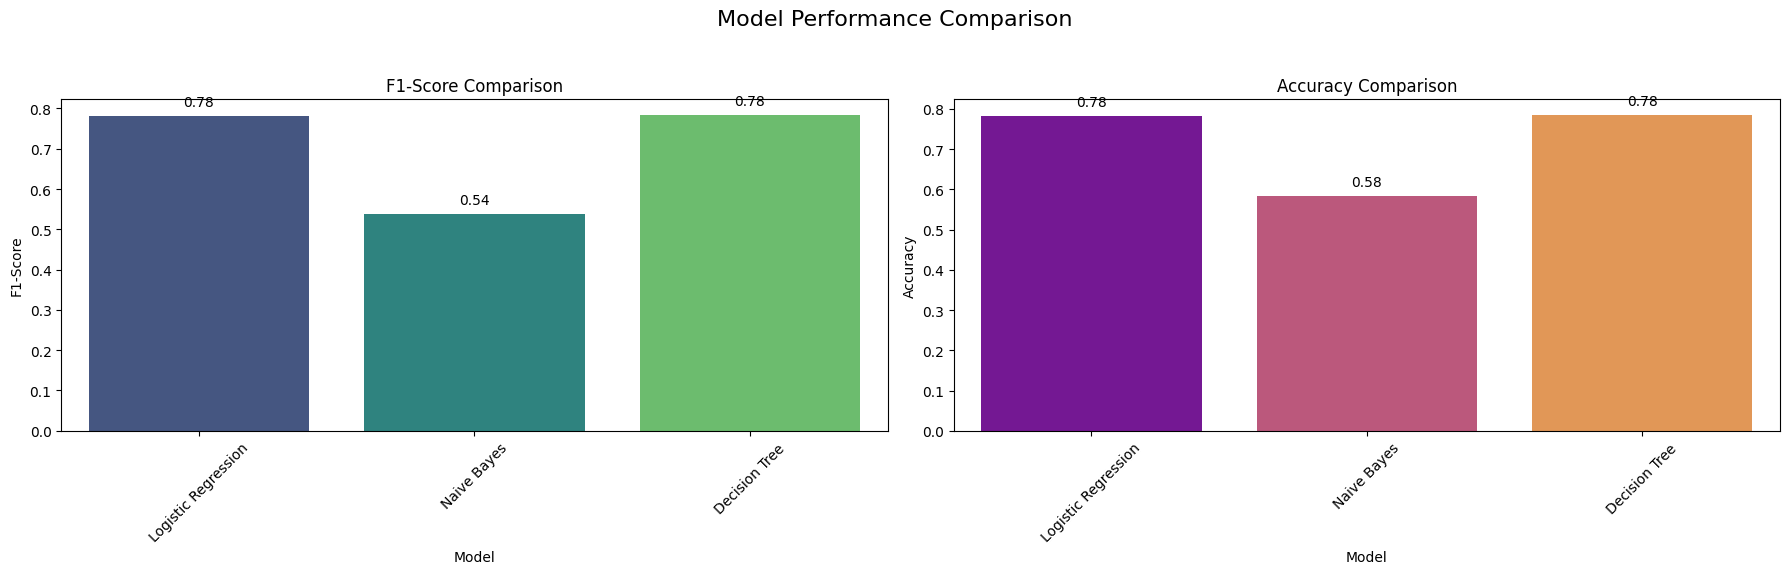

In [69]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Plotting Model Performance
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Model Performance Comparison', fontsize=16)

# Plotting F1-Score
sns.barplot(x=results_df.index, y='F1-Score', hue=results_df.index, data=results_df, ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('F1-Score Comparison')
axes[0].set_ylabel('F1-Score')
axes[0].set_xlabel('Model')
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# Plotting Accuracy
sns.barplot(x=results_df.index, y='Accuracy', hue=results_df.index, data=results_df, ax=axes[1], palette='plasma', legend=False)
axes[1].set_title('Accuracy Comparison')
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Feature Engineering Choice

Both Bag of Words and TF-IDF were implemented. TF-IDF was selected for model training because it assigns higher importance to meaningful words and reduces the impact of commonly occurring words, leading to better performance in sentiment analysis tasks.

## Final Insights & Conclusion

- TF-IDF performed better than Bag of Words as it captures word importance.
- Logistic Regression achieved the best performance due to its efficiency with high-dimensional text data.
- Naive Bayes performed well and was computationally efficient.
- Decision Tree showed comparatively lower performance due to overfitting tendencies.

Final Conclusion:
TF-IDF combined with Logistic Regression is the most effective approach for this sentiment analysis t